<a href="https://colab.research.google.com/github/helloayana/pneumonia-detection/blob/main/pneumonia_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install kaggle -q
!mkdir -p ~/.kaggle
!echo "KGAT_7303628c474c6150595697490b76bb69" > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip -d data

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
 40% 940M/2.29G [00:42<01:03, 23.3MB/s]
User cancelled operation
[chest-xray-pneumonia.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of chest-xray-pneumonia.zip or
        chest-xray-pneumonia.zip.zip, and cannot find chest-xray-pneumonia.zip.ZIP, period.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install kaggle -q
!mkdir -p ~/.kaggle
!echo "KGAT_7303628c474c6150595697490b76bb69" > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip -d /content/drive/MyDrive/pneumonia_project/data

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
Resuming from 985661440 bytes (1477703995 bytes left)...
100% 2.29G/2.29G [01:05<00:00, 22.5MB/s]



In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224, 224)
batch_size = 32

data_path = '/content/drive/MyDrive/pneumonia_project/data/chest_xray'

train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=15, zoom_range=0.1, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(f'{data_path}/train', target_size=img_size, batch_size=batch_size, class_mode='binary')
val_gen = val_datagen.flow_from_directory(f'{data_path}/val', target_size=img_size, batch_size=batch_size, class_mode='binary')
test_gen = val_datagen.flow_from_directory(f'{data_path}/test', target_size=img_size, batch_size=batch_size, class_mode='binary', shuffle=False)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [3]:
from tensorflow.keras.models import load_model
model = load_model('/content/drive/MyDrive/pneumonia_project/model.keras')

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224, 224)
batch_size = 32
data_path = '/content/drive/MyDrive/pneumonia_project/data/chest_xray'

train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=15, zoom_range=0.1, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(f'{data_path}/train', target_size=img_size, batch_size=batch_size, class_mode='binary')
val_gen = val_datagen.flow_from_directory(f'{data_path}/val', target_size=img_size, batch_size=batch_size, class_mode='binary')
test_gen = val_datagen.flow_from_directory(f'{data_path}/test', target_size=img_size, batch_size=batch_size, class_mode='binary', shuffle=False)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [4]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight('balanced', classes=np.unique(train_gen.classes), y=train_gen.classes)
class_weights_dict = dict(enumerate(class_weights))

In [5]:
from tensorflow.keras.models import load_model
model = load_model('/content/drive/MyDrive/pneumonia_project/model.keras')

In [7]:
import os
for split in ['train', 'val', 'test']:
    for cls in ['NORMAL', 'PNEUMONIA']:
        path = f'data/chest_xray/{split}/{cls}'
        print(split, cls, len(os.listdir(path)))

train NORMAL 1341
train PNEUMONIA 3875
val NORMAL 8
val PNEUMONIA 8
test NORMAL 234
test PNEUMONIA 390


In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=15, zoom_range=0.1, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory('data/chest_xray/train', target_size=img_size, batch_size=batch_size, class_mode='binary')
val_gen = val_datagen.flow_from_directory('data/chest_xray/val', target_size=img_size, batch_size=batch_size, class_mode='binary')
test_gen = val_datagen.flow_from_directory('data/chest_xray/test', target_size=img_size, batch_size=batch_size, class_mode='binary', shuffle=False)


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [9]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

base_model = MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight('balanced', classes=np.unique(train_gen.classes), y=train_gen.classes)
class_weights_dict = dict(enumerate(class_weights))
print(class_weights_dict)

{0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


In [11]:
history = model.fit(train_gen, validation_data=val_gen, epochs=10, class_weight=class_weights_dict)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 349s 2s/step - accuracy: 0.9126 - loss: 0.2052 - val_accuracy: 0.8750 - val_loss: 0.2680
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 330s 2s/step - accuracy: 0.9431 - loss: 0.1336 - val_accuracy: 0.8750 - val_loss: 0.2656
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step - accuracy: 0.9498 - loss: 0.1199 - val_accuracy: 0.9375 - val_loss: 0.1938
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 326s 2s/step - accuracy: 0.9546 - loss: 0.1084 - val_accuracy: 0.8125 - val_loss: 0.3585
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 318s 2s/step - accuracy: 0.9549 - loss: 0.1044 - val_accuracy: 0.8125 - val_loss: 0.2394
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 334s 2s/step - accuracy: 0.9601 - loss: 0.0936 - val_accuracy: 0.8750 - val_loss: 0.1915
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 321s 2s/step - accuracy: 0.9595 - loss: 0.0977 - val_accuracy: 0.9375 - val_loss: 0.1614
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 332s 2s/step - accuracy: 0.9624 - loss: 0.0923 - val_accu

In [12]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/pneumonia_project', exist_ok=True)

model.save('/content/drive/MyDrive/pneumonia_project/model.keras')

Mounted at /content/drive


In [13]:
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test accuracy: {test_acc:.2%}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.8894 - loss: 0.3132
Test accuracy: 88.94%


20/20 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step


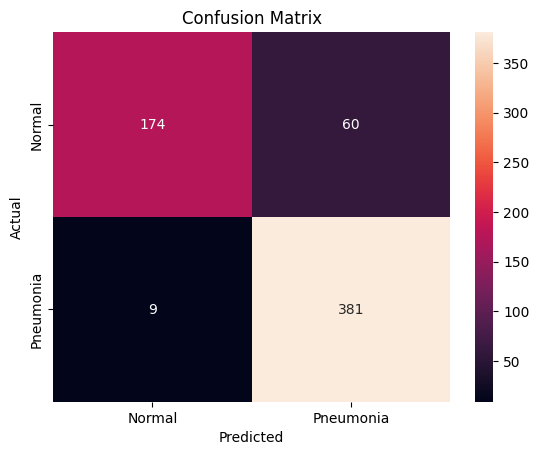

              precision    recall  f1-score   support

      Normal       0.95      0.74      0.83       234
   Pneumonia       0.86      0.98      0.92       390

    accuracy                           0.89       624
   macro avg       0.91      0.86      0.88       624
weighted avg       0.90      0.89      0.89       624



In [14]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

preds = model.predict(test_gen)
pred_labels = (preds > 0.5).astype(int).flatten()
true_labels = test_gen.classes

cm = confusion_matrix(true_labels, pred_labels)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Normal','Pneumonia'], yticklabels=['Normal','Pneumonia'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()

print(classification_report(true_labels, pred_labels, target_names=['Normal','Pneumonia']))

In [15]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np

uploaded = files.upload()  # появится кнопка "Choose Files" — выбери фото рентгена со своего компа
fn = list(uploaded.keys())[0]

img = image.load_img(fn, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)[0][0]
label = "Pneumonia" if pred > 0.5 else "Normal"
confidence = pred if pred > 0.5 else 1 - pred

print(f"Предсказание: {label} (уверенность: {confidence:.1%})")

Saving 93fa6c67-187d-4ee8-88ca-5b66cc02e697.jpg to 93fa6c67-187d-4ee8-88ca-5b66cc02e697.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Предсказание: Normal (уверенность: 99.9%)


In [5]:
model.save('/content/drive/MyDrive/pneumonia_project/model_v1_frozen.keras')

In [7]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Разморожено слоёв: {trainable_count} из {len(base_model.layers)}")

NameError: name 'base_model' is not defined

In [8]:
# Сначала посмотрим, сколько всего слоёв и как называются последние
print(f"Всего слоёв: {len(model.layers)}")
for i, layer in enumerate(model.layers[-25:]):
    print(i, layer.name, layer.trainable)

Всего слоёв: 158
0 block_14_add False
1 block_15_expand False
2 block_15_expand_BN False
3 block_15_expand_relu False
4 block_15_depthwise False
5 block_15_depthwise_BN False
6 block_15_depthwise_relu False
7 block_15_project False
8 block_15_project_BN False
9 block_15_add False
10 block_16_expand False
11 block_16_expand_BN False
12 block_16_expand_relu False
13 block_16_depthwise False
14 block_16_depthwise_BN False
15 block_16_depthwise_relu False
16 block_16_project False
17 block_16_project_BN False
18 Conv_1 False
19 Conv_1_bn False
20 out_relu False
21 global_average_pooling2d_1 True
22 dense_2 True
23 dropout_1 True
24 dense_3 True


In [9]:
model.trainable = True

# Замораживаем всё, кроме последних 24 слоёв
# (20 последних слоёв MobileNetV2 + 4 слоя твоей головы: GAP, Dense, Dropout, Dense)
for layer in model.layers[:-24]:
    layer.trainable = False

trainable_count = sum(1 for l in model.layers if l.trainable)
print(f"Разморожено слоёв: {trainable_count} из {len(model.layers)}")

Разморожено слоёв: 4 из 158


In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
# Шаг 1: заморозить АБСОЛЮТНО всё, без исключений
for layer in model.layers:
    layer.trainable = False

# Шаг 2: явно разморозить последние 24 слоя (это точно сработает, в отличие от прошлого раза)
for layer in model.layers[-24:]:
    layer.trainable = True

trainable_count = sum(1 for l in model.layers if l.trainable)
print(f"Разморожено слоёв: {trainable_count} из {len(model.layers)}")

Разморожено слоёв: 24 из 158


In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 1,370,177 (5.23 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

In [6]:
history_fine = model.fit(
    train_gen, validation_data=val_gen, epochs=5,
    class_weight=class_weights_dict
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1480s 9s/step - accuracy: 0.9663 - loss: 0.0870 - val_accuracy: 0.9375 - val_loss: 0.1815
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 341s 2s/step - accuracy: 0.9670 - loss: 0.0822 - val_accuracy: 0.9375 - val_loss: 0.1210
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 363s 2s/step - accuracy: 0.9645 - loss: 0.0845 - val_accuracy: 1.0000 - val_loss: 0.1300
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 382s 2s/step - accuracy: 0.9618 - loss: 0.0898 - val_accuracy: 0.9375 - val_loss: 0.1388
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 347s 2s/step - accuracy: 0.9649 - loss: 0.0854 - val_accuracy: 0.9375 - val_loss: 0.1227


In [7]:
model.save('/content/drive/MyDrive/pneumonia_project/model_v2_finetuned.keras')

In [8]:
test_loss_v2, test_acc_v2 = model.evaluate(test_gen)
print(f"Fine-tuned model — Test accuracy: {test_acc_v2:.2%}")
print(f"Было (v1, только заморозка): 88.94%")
print(f"Стало (v2, fine-tuned): {test_acc_v2:.2%}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 540s 28s/step - accuracy: 0.9071 - loss: 0.2568
Fine-tuned model — Test accuracy: 90.71%
Было (v1, только заморозка): 88.94%
Стало (v2, fine-tuned): 90.71%


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


20/20 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step


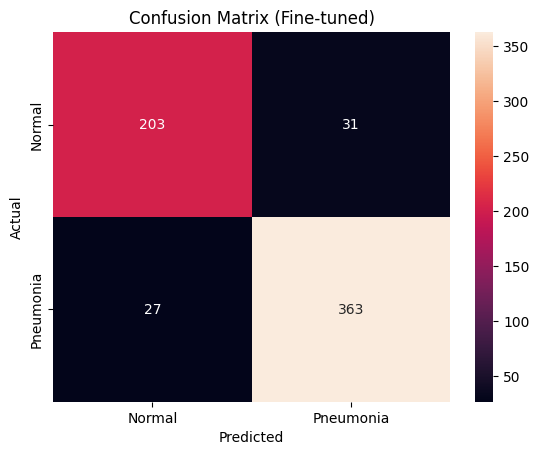

              precision    recall  f1-score   support

      Normal       0.88      0.87      0.88       234
   Pneumonia       0.92      0.93      0.93       390

    accuracy                           0.91       624
   macro avg       0.90      0.90      0.90       624
weighted avg       0.91      0.91      0.91       624



In [9]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

preds = model.predict(test_gen)
pred_labels = (preds > 0.5).astype(int).flatten()
true_labels = test_gen.classes

cm = confusion_matrix(true_labels, pred_labels)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Normal','Pneumonia'], yticklabels=['Normal','Pneumonia'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix (Fine-tuned)')
plt.show()

print(classification_report(true_labels, pred_labels, target_names=['Normal','Pneumonia']))